## **Part 1 Exploratory Data Analysis**
a.  Given the provided dataset can you provide insights on how **request volume** and **Completion Rate (CR = total_completed_trips/total_requests)** changes throughout time? Do you think request volume is an accurate measure of demand?


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Install a library
!pip install pandasql

  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26781 sha256=7b9c3e0215821911340215de1f1a7e1c83e2048ca6a6a63f851d0b23eef0e368
  Stored in directory: /root/.cache/pip/wheels/5c/4b/ec/41f4e116c8053c3654e2c2a47c62b4fca34cc67ef7b55deb7f
Successfully built pandasql


In [ ]:
## Data Analysis Phase
## MAin aim is to understand more about the data

# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from plotnine import *
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
%matplotlib inline
import json
import pandasql
## Display all the columns of the dataframe

pd.pandas.set_option('display.max_columns',None)

#### **Loading Data**

In [ ]:
df_request = pd.read_csv('/content/drive/My Drive/pathao_assignment/raw_request_dataset.csv')
df_completed = pd.read_csv('/content/drive/My Drive/pathao_assignment/monthly_completed_trip.csv')
df_ride = pd.read_csv('/content/drive/My Drive/pathao_assignment/driver_ride_assignments.csv')


In [ ]:
df_request.shape


(106139, 11)

In [ ]:
df_completed.shape

(4797, 2)

In [ ]:
df_ride.shape

(238559, 2)

In [ ]:
df_request.head()

,day_of_week,Hour,Minute,ride_id,passenger_id,driver_id,undiscounted_fare,rating,ride_duration,ride_distance,status
0,1,5,48,78A5RS,4194635,5271687,121.0,NaN,651.0,6077.0,COMPLETED
1,1,7,37,78A9FQ,5390069,3801157,116.0,NaN,1375.0,5733.0,COMPLETED
2,1,7,47,78AACQ,3750224,5102685,194.0,4.0,1566.0,10913.0,COMPLETED
3,1,8,27,78AFLP,4419899,4869168,66.0,1.0,306.0,2430.0,COMPLETED
4,1,8,41,78AIEB,3802452,2928777,130.0,5.0,1088.0,6686.0,COMPLETED


In [ ]:
df_completed.head()

,driver_id,total_monthly_trips
0,4700650,102
1,5160519,336
2,4712145,183
3,5334092,63
4,5124702,274


In [ ]:
df_ride.head()

,ride_id,driver_id
0,78A5D3,4922405
1,78A5D3,5332197
2,78A604,5303157
3,78A604,3355215
4,78A604,5265495


In Data Analysis We will Analyze To Find out the below stuff
* Missing Values
* All The Numerical Variables
* Distribution of the Numerical Variables
* Outliers
* Relationship between independent and dependent feature(SalePrice)

### **Analysis of demand and Reliability according Day-wise**

In [ ]:
days= list(df_request['day_of_week'])
Unique_days= list(df_request.day_of_week.unique())
print(len(days))
print(Unique_days)
print(len(Unique_days))

106139
[1, 2, 3, 4, 5, 6, 7]
7


In [ ]:
query1 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request group by day_of_week
            
        '''

output1 = pandasql.sqldf(query1, globals())

In [ ]:
print(output1)

   ride_request
0         17299
1         16847
2         15647
3         16814
4         16136
5         11906
6         11490


In [ ]:
total_requests=list(output1['ride_request'])
print(total_requests)

[17299, 16847, 15647, 16814, 16136, 11906, 11490]


In [ ]:
query2 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED'
            group by day_of_week 
            
        '''

output2 = pandasql.sqldf(query2, globals())

In [ ]:
print(output2)

   completed_trip
0            9359
1           10206
2            9224
3            8419
4            9112
5            2989
6            7229


In [ ]:
total_completed_trips=list(output2['completed_trip'])
print(total_completed_trips)

[9359, 10206, 9224, 8419, 9112, 2989, 7229]


In [ ]:
Completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_completed_trips, total_requests)]


In [ ]:
print(Completion_Rate)


[54.1, 60.58, 58.95, 50.07, 56.47, 25.1, 62.92]


In [ ]:
total_cancelled_trips=[ (i - j ) for i, j in zip(total_requests,total_completed_trips)]
Cancellation_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_cancelled_trips, total_requests)]

In [ ]:
raw_data ={
            'Day_of_Week': Unique_days,
            'Demand':total_requests,
            'Total Completed Trips':total_completed_trips,
            'Total cancelled trips':total_cancelled_trips,
            'Completion Rate (%)':Completion_Rate,
            'Cancellation Rate (%)':Cancellation_Rate,
            'Reliability':Completion_Rate
            }
df_day=pd.DataFrame(raw_data,columns=['Day_of_Week','Demand','Total Completed Trips','Total cancelled trips','Completion Rate (%)','Cancellation Rate (%)','Reliability'])

print(df_day)
print("ok")

   Day_of_Week  Demand  Total Completed Trips  Total cancelled trips  \
0            1   17299                   9359                   7940   
1            2   16847                  10206                   6641   
2            3   15647                   9224                   6423   
3            4   16814                   8419                   8395   
4            5   16136                   9112                   7024   
5            6   11906                   2989                   8917   
6            7   11490                   7229                   4261   

   Completion Rate (%)  Cancellation Rate (%)  Reliability  
0                54.10                  45.90        54.10  
1                60.58                  39.42        60.58  
2                58.95                  41.05        58.95  
3                50.07                  49.93        50.07  
4                56.47                  43.53        56.47  
5                25.10                  74.90        25.1

Text(0.5, 1.0, 'Demand of Riding  Daywise')

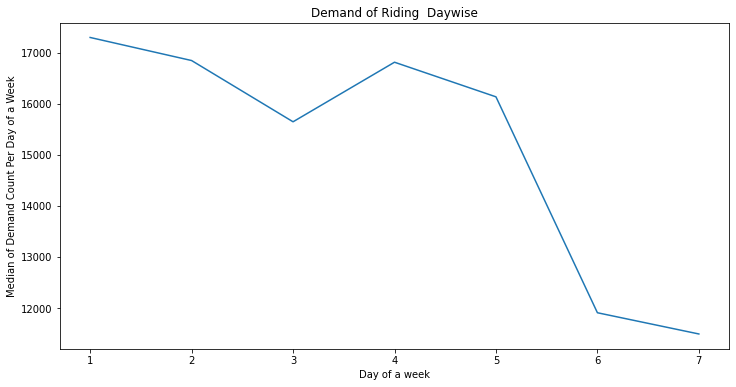

In [ ]:
## Lets analyze  how request volumn changes throughout time
## We will check whether there is a relation between total requests per hour and each hour of the request

fig, axes = plt.subplots(figsize=(12, 6), sharex=True)

df_day.groupby('Day_of_Week')['Demand'].median().plot()
plt.xlabel('Day of a week')
plt.ylabel('Median of Demand Count Per Day of a Week')
plt.title("Demand of Riding  Daywise")

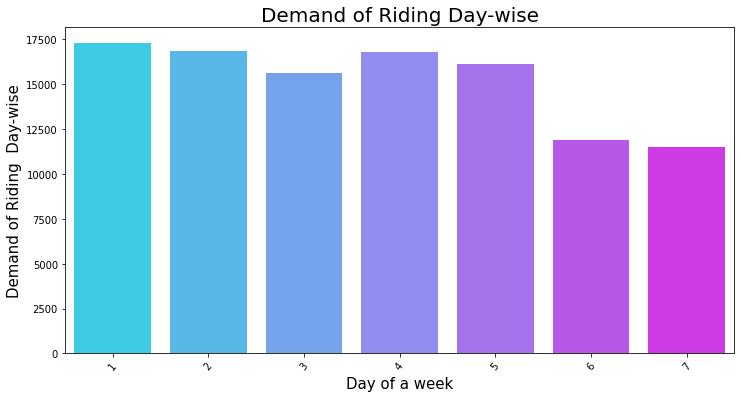

In [ ]:

plt.figure(figsize = (12,6))
sns.barplot(x='Day_of_Week',y='Demand',data=df_day, palette='cool')
plt.xticks(rotation=50)
plt.xlabel('Day of a week',fontsize=15)
plt.ylabel('Demand of Riding  Day-wise',fontsize=15)
plt.title("Demand of Riding Day-wise",fontsize=20)
plt.show()

Text(0.5, 1.0, 'Percentage(%) of Completed Demand Day-Wise')

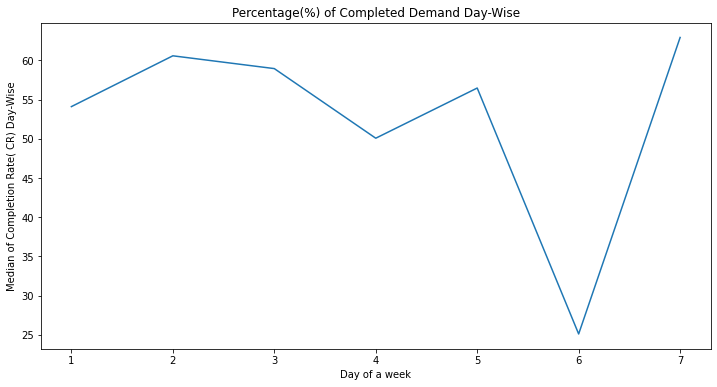

In [ ]:
## Lets analyze how Completion Rate changes throughout time
## We will check whether there is a relation between total Completion Rate and the day od a week in when the request assigns.

fig, axes = plt.subplots(figsize=(12, 6), sharex=True)

df_day.groupby('Day_of_Week')['Completion Rate (%)'].median().plot()
plt.xlabel('Day of a week')
plt.ylabel('Median of Completion Rate( CR) Day-Wise')
plt.title("Percentage(%) of Completed Demand Day-Wise")

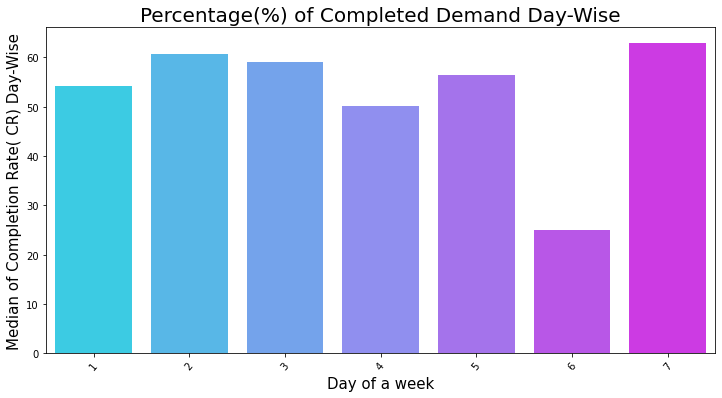

In [ ]:
plt.figure(figsize = (12,6))
sns.barplot(x='Day_of_Week',y='Completion Rate (%)',data=df_day, palette='cool')
plt.xticks(rotation=50)
plt.xlabel('Day of a week',fontsize=15)
plt.ylabel('Median of Completion Rate( CR) Day-Wise',fontsize=15)
plt.title("Percentage(%) of Completed Demand Day-Wise",fontsize=20)
plt.show()

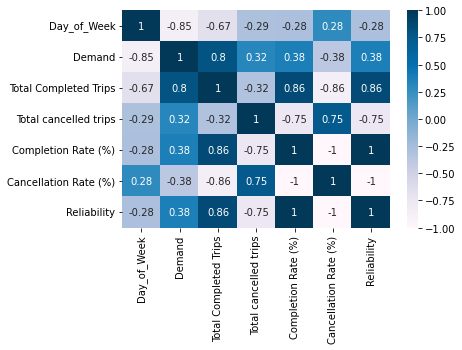

In [ ]:
# compare linear relationships between attributes using correlation coefficient generated using
    # correlation matrix
sns.heatmap(df_day.corr(), cmap = 'PuBu', annot = True)
plt.show()

In [ ]:
df_day[df_day.columns[:]].corr()['Reliability'][:]

Day_of_Week             -0.282119
Demand                   0.378987
Total Completed Trips    0.858578
Total cancelled trips   -0.749314
Completion Rate (%)      1.000000
Cancellation Rate (%)   -1.000000
Reliability              1.000000
Name: Reliability, dtype: float64

### **Observation**
In case of Demand of riding day-wise of a week ; we can say that,
- From the above line-plot and count-plot in case of x='Day_of_Week' and y='Demand', we can say that Demand (request volumn) differs according days in a week where Sunday and Monday the demand is high on the other hand in case of friday and staurday it is low. May be it's because most of the offices and other organizations are open from sunday and many of them are keeping off during friday and saturday.

In case of % of Demand Completion Rate day-wise of a week ; we can say that,
- From the above line-plot and count-plot in case of x='Day_of_Week',y='Completion Rate (%)', we can say that % of Completion Rate (reliability) differs according to days in a week where inspite of friday and staturday the demand is low but the completion rate is high during saturday but again low during friday.May be it's because of of workers and drivers also takes holiday in friday..!

### **Correlation Analysis:**
Here from the correlation between Reliability with other attributes we can observe that,
- correlation between Reliability and Total cancelled trips, Cancellation Rate(%) and Day_of_Week is negatiive, which means if the value of Total cancelled trips and Cancellation Rate(%) will increase then the value of reliability will decrease  and if the value of Total cancelled trips and Cancellation Rate(%) will deccrease then the value of reliability will increase.
-  correlation between Reliability and Total completed trips, Completion Rate(%) and Demand is positive, which means if the value of Total completed trips, Completion Rate(%) and Demand will increase then the value of reliability will also increase  and if the value of Total cancelled trips and Cancellation Rate(%) will deccrease then the value of reliability will also decrease.

### **Analysis of demand and Reliability according Hour-wise**

In [ ]:
query3 = '''
            SELECT 
                Hour,count(ride_id) as ride_request
                      
            FROM 
                df_request group by Hour
            
        '''

output3 = pandasql.sqldf(query3, globals())

In [ ]:
print(output3)

    Hour  ride_request
0      0           451
1      1           251
2      2           188
3      3           120
4      4           163
5      5          1132
6      6          2217
7      7          2724
8      8          4783
9      9          8645
10    10          8208
11    11          6674
12    12          6225
13    13          6673
14    14          5997
15    15          6243
16    16          6712
17    17          7844
18    18          8242
19    19          7861
20    20          6034
21    21          4800
22    22          2800
23    23          1152


Here, we have calculated the total number of assigned request to drivers per each particular time or hours in a day.

In [ ]:
total_requests=list(output3['ride_request'])
Unique_Hours=list(output3['Hour'])
print(total_requests)
print(Unique_Hours)

[451, 251, 188, 120, 163, 1132, 2217, 2724, 4783, 8645, 8208, 6674, 6225, 6673, 5997, 6243, 6712, 7844, 8242, 7861, 6034, 4800, 2800, 1152]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [ ]:
query4 = '''
            SELECT 
              Hour,count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED'
            group by Hour 
            
        '''

output4 = pandasql.sqldf(query4, globals())

In [ ]:
print(output4)

    Hour  completed_trip
0      0             143
1      1              62
2      2              51
3      3              42
4      4              66
5      5             443
6      6            1161
7      7            1524
8      8            2639
9      9            4047
10    10            4128
11    11            3725
12    12            3649
13    13            3801
14    14            3246
15    15            3695
16    16            3987
17    17            4355
18    18            4471
19    19            4089
20    20            3119
21    21            2328
22    22            1303
23    23             464


In [ ]:
total_completed_trips=list(output4['completed_trip'])
print(total_completed_trips)

[143, 62, 51, 42, 66, 443, 1161, 1524, 2639, 4047, 4128, 3725, 3649, 3801, 3246, 3695, 3987, 4355, 4471, 4089, 3119, 2328, 1303, 464]


In [ ]:
Completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_completed_trips, total_requests)]

In [ ]:
print(Completion_Rate)

[31.71, 24.7, 27.13, 35.0, 40.49, 39.13, 52.37, 55.95, 55.17, 46.81, 50.29, 55.81, 58.62, 56.96, 54.13, 59.19, 59.4, 55.52, 54.25, 52.02, 51.69, 48.5, 46.54, 40.28]


In [ ]:
total_cancelled_trips=[ (i - j ) for i, j in zip(total_requests,total_completed_trips)]

In [ ]:
Cancellation_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(total_cancelled_trips, total_requests)]

In [ ]:
raw_data ={
            'Hour': Unique_Hours,
            'Demand':total_requests,
            'Total Completed Trips':total_completed_trips,
            'Total cancelled trips':total_cancelled_trips,
            'Completion Rate (%)':Completion_Rate,
            'Cancellation Rate (%)':Cancellation_Rate,
            'Reliability':Completion_Rate
            }
df_CR=pd.DataFrame(raw_data,columns=['Hour','Demand','Total Completed Trips','Total cancelled trips','Completion Rate (%)','Cancellation Rate (%)','Reliability'])

print(df_CR)
print("ok")

    Hour  Demand  Total Completed Trips  Total cancelled trips  \
0      0     451                    143                    308   
1      1     251                     62                    189   
2      2     188                     51                    137   
3      3     120                     42                     78   
4      4     163                     66                     97   
5      5    1132                    443                    689   
6      6    2217                   1161                   1056   
7      7    2724                   1524                   1200   
8      8    4783                   2639                   2144   
9      9    8645                   4047                   4598   
10    10    8208                   4128                   4080   
11    11    6674                   3725                   2949   
12    12    6225                   3649                   2576   
13    13    6673                   3801                   2872   
14    14  

Text(0.5, 1.0, 'Demand of Riding  Hourwise')

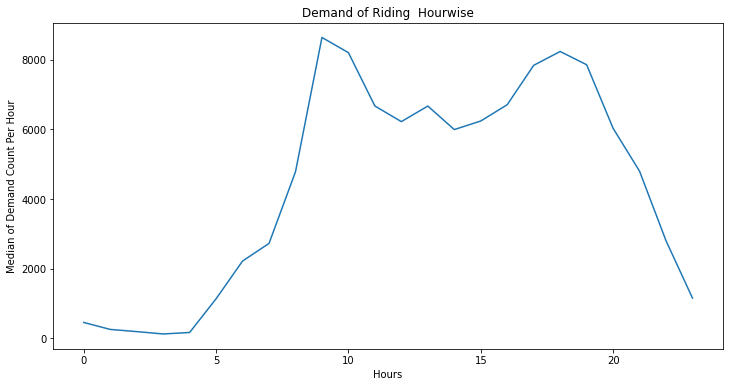

In [ ]:
## Lets analyze  how request volumn changes throughout time
## We will check whether there is a relation between total requests per hour and each hour of the request

fig, axes = plt.subplots(figsize=(12, 6), sharex=True)

df_CR.groupby('Hour')['Demand'].median().plot()
plt.xlabel('Hours')
plt.ylabel('Median of Demand Count Per Hour')
plt.title("Demand of Riding  Hourwise")

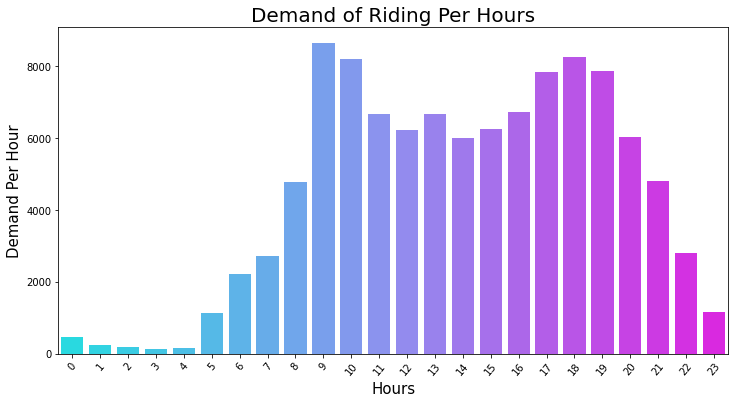

In [ ]:

plt.figure(figsize = (12,6))
sns.barplot(x='Hour',y='Demand',data=df_CR, palette='cool')
plt.xticks(rotation=50)
plt.xlabel('Hours',fontsize=15)
plt.ylabel('Demand Per Hour',fontsize=15)
plt.title("Demand of Riding Per Hours",fontsize=20)
plt.show()

### **How Completion Rate (CR = total_completed_trips/total_requests) changes throughout time -**

Text(0.5, 1.0, 'Percentage(%) of Completed Demand Hourwise')

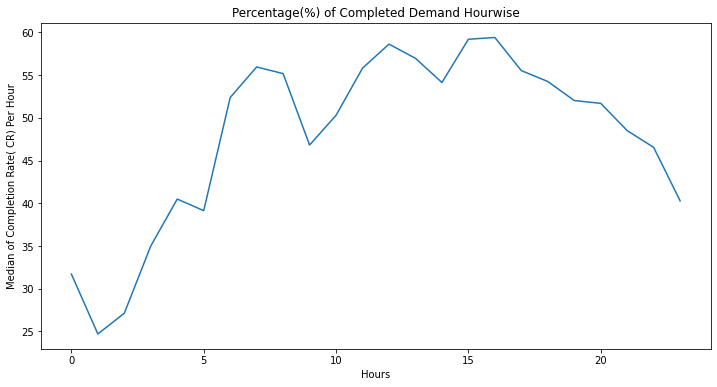

In [ ]:
## Lets analyze how Completion Rate changes throughout time
## We will check whether there is a relation between total Completion Rate and the hour in when the request assigns.

fig, axes = plt.subplots(figsize=(12, 6), sharex=True)

df_CR.groupby('Hour')['Completion Rate (%)'].median().plot()
plt.xlabel('Hours')
plt.ylabel('Median of Completion Rate( CR) Per Hour')
plt.title("Percentage(%) of Completed Demand Hourwise")

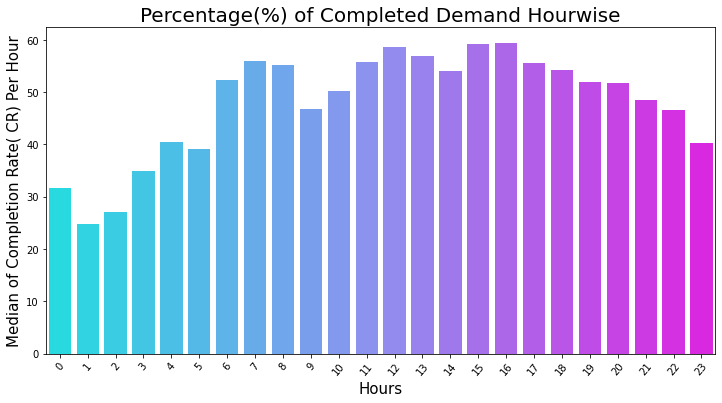

In [ ]:
plt.figure(figsize = (12,6))
sns.barplot(x='Hour',y='Completion Rate (%)',data=df_CR, palette='cool')
plt.xticks(rotation=50)
plt.xlabel('Hours',fontsize=15)
plt.ylabel('Median of Completion Rate( CR) Per Hour',fontsize=15)
plt.title("Percentage(%) of Completed Demand Hourwise",fontsize=20)
plt.show()

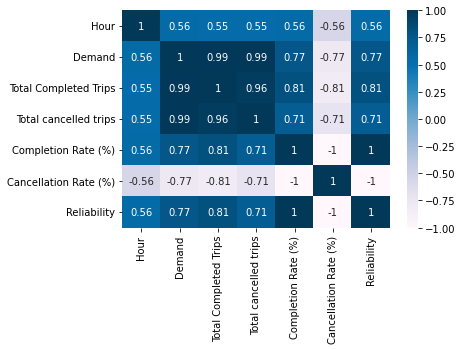

In [ ]:
# compare linear relationships between attributes using correlation coefficient generated using
    # correlation matrix
sns.heatmap(df_CR.corr(), cmap = 'PuBu', annot = True)
plt.show()

In [ ]:
df_CR[df_CR.columns[:]].corr()['Reliability'][:]

Hour                     0.559676
Demand                   0.772871
Total Completed Trips    0.814704
Total cancelled trips    0.706356
Completion Rate (%)      1.000000
Cancellation Rate (%)   -1.000000
Reliability              1.000000
Name: Reliability, dtype: float64

### **Observation**
In case of Demand of riding day-wise of a week ; we can say that,
- From the above line-plot and count-plot in case of x='Hour' and y='Demand', we can say that Demand (request volumn) differs according Hours in a day where arround 9 to 10 AM and 6 to 7 the demand is high on the other hand in arround 4 to 5 PM it is low. May be it's because most of the offices and other organizations starts arround 9 AM and many of then closes arround 5 PM.

In case of % of Demand Completion Rate day-wise of a week ; we can say that,
- From the above line-plot and count-plot in case of x='Hour',y='Completion Rate (%)', we can say that % of Completion Rate (reliability) differs according to Hours in a day where arround 7 to 8 AM the Reliability is high on the other hand in arround 3 to 4 PM it is low. May be it's because most of the offices and other organizations starts arround 9 AM and many of then closes arround 5 PM.

### **Correlation Analysis:**
Here from the correlation between Reliability with other attributes we can observe that,
- correlation between Reliability and Cancellation Rate(%) is negatiive, which means if the value of Total cancelled trips and Cancellation Rate(%) will increase then the value of reliability will decrease  and if the value of Total cancelled trips and Cancellation Rate(%) will deccrease then the value of reliability will increase.
-  correlation between Reliability and Total completed trips, Completion Rate(%) and Demand is positive, which means if the value of Total completed trips, Completion Rate(%) and Demand will increase then the value of reliability will also increase  and if the value of Total cancelled trips and Cancellation Rate(%) will deccrease then the value of reliability will also decrease.

### **Analysis of demand and Reliability according to Hours Per Days**

In [ ]:
query5 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 1 group by Hour
            
        '''
query6 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 1
            group by Hour 
            
        '''

sun_output1 = pandasql.sqldf(query5, globals())
sun_output2 = pandasql.sqldf(query6, globals())

In [ ]:
sun_total_requests=list(sun_output1['ride_request'])
print(sun_total_requests)
sun_total_completed_trips=list(sun_output2['completed_trip'])
print(sun_total_completed_trips)
sun_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(sun_total_completed_trips, sun_total_requests)]

[70, 79, 27, 24, 35, 179, 366, 446, 693, 1387, 1549, 1267, 1204, 1051, 829, 1104, 994, 1057, 1666, 1339, 870, 576, 339, 148]
[12, 11, 12, 7, 12, 84, 243, 304, 511, 794, 837, 787, 772, 656, 437, 635, 552, 419, 644, 615, 446, 316, 191, 62]


In [ ]:
query7 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 2 group by Hour
            
        '''
query8 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 2
            group by Hour 
            
        '''

mon_output1 = pandasql.sqldf(query7, globals())
mon_output2 = pandasql.sqldf(query8, globals())

In [ ]:
mon_total_requests=list(mon_output1['ride_request'])
print(mon_total_requests)
mon_total_completed_trips=list(mon_output2['completed_trip'])
print(mon_total_completed_trips)
mon_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(mon_total_completed_trips, mon_total_requests)]

[59, 26, 26, 13, 33, 160, 382, 502, 849, 1403, 1283, 1155, 1110, 1120, 1004, 1046, 1143, 1255, 1252, 1099, 802, 627, 345, 153]
[17, 7, 7, 5, 13, 98, 253, 331, 536, 769, 736, 705, 670, 712, 637, 651, 723, 805, 782, 651, 459, 375, 193, 71]


In [ ]:
query9 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 3 group by Hour
            
        '''
query10 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 3
            group by Hour 
            
        '''

tue_output1 = pandasql.sqldf(query9, globals())
tue_output2 = pandasql.sqldf(query10, globals())

In [ ]:
tue_total_requests=list(tue_output1['ride_request'])
print(tue_total_requests)
tue_total_completed_trips=list(tue_output2['completed_trip'])
print(tue_total_completed_trips)
tue_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(tue_total_completed_trips, tue_total_requests)]

[77, 30, 17, 13, 18, 141, 307, 432, 758, 1174, 1154, 1084, 1041, 973, 706, 906, 1045, 1299, 1192, 1202, 821, 686, 423, 148]
[23, 8, 6, 3, 6, 77, 180, 296, 506, 740, 670, 685, 664, 631, 359, 569, 606, 741, 710, 680, 499, 356, 160, 49]


In [ ]:
query11 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 4 group by Hour
            
        '''
query12 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 4
            group by Hour 
            
        '''

wed_output1 = pandasql.sqldf(query9, globals())
wed_output2 = pandasql.sqldf(query10, globals())

In [ ]:
wed_total_requests=list(wed_output1['ride_request'])
print(wed_total_requests)
wed_total_completed_trips=list(wed_output2['completed_trip'])
print(wed_total_completed_trips)
wed_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(wed_total_completed_trips, wed_total_requests)]

[77, 30, 17, 13, 18, 141, 307, 432, 758, 1174, 1154, 1084, 1041, 973, 706, 906, 1045, 1299, 1192, 1202, 821, 686, 423, 148]
[23, 8, 6, 3, 6, 77, 180, 296, 506, 740, 670, 685, 664, 631, 359, 569, 606, 741, 710, 680, 499, 356, 160, 49]


In [ ]:
query13 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 5 group by Hour
            
        '''
query14 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 5
            group by Hour 
            
        '''

thur_output1 = pandasql.sqldf(query13, globals())
thur_output2 = pandasql.sqldf(query14, globals())

In [ ]:
thur_total_requests=list(thur_output1['ride_request'])
print(thur_total_requests)
thur_total_completed_trips=list(thur_output2['completed_trip'])
print(thur_total_completed_trips)
thur_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(thur_total_completed_trips, thur_total_requests)]

[53, 24, 16, 19, 19, 219, 385, 337, 701, 1515, 1458, 1010, 926, 952, 972, 1040, 1076, 1178, 1210, 1069, 802, 574, 434, 147]
[25, 10, 5, 7, 10, 70, 185, 182, 416, 735, 720, 552, 618, 605, 612, 659, 715, 762, 705, 574, 437, 277, 186, 45]


In [ ]:
query15 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 6 group by Hour
            
        '''
query16 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 6
            group by Hour 
            
        '''

fri_output1 = pandasql.sqldf(query15, globals())
fri_output2 = pandasql.sqldf(query16, globals())

In [ ]:
fri_total_requests=list(fri_output1['ride_request'])
print(fri_total_requests)
fri_total_completed_trips=list(fri_output2['completed_trip'])
print(fri_total_completed_trips)
fri_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(fri_total_completed_trips, fri_total_requests)]

[51, 31, 34, 10, 11, 151, 251, 329, 471, 917, 844, 637, 530, 500, 563, 528, 674, 829, 888, 956, 1038, 994, 424, 245]
[16, 7, 4, 2, 2, 18, 84, 115, 129, 157, 158, 173, 165, 164, 159, 134, 206, 236, 251, 218, 222, 193, 111, 65]


In [ ]:
query17 = '''
            SELECT 
                count(ride_id) as ride_request
                      
            FROM 
                df_request where day_of_week = 7 group by Hour
            
        '''
query18 = '''
            SELECT 
              count(*) as completed_trip
                      
            FROM 
                df_request 
            where status='COMPLETED' AND day_of_week = 7
            group by Hour 
            
        '''

sat_output1 = pandasql.sqldf(query17, globals())
sat_output2 = pandasql.sqldf(query18, globals())

In [ ]:
sat_total_requests=list(sat_output1['ride_request'])
print(sat_total_requests)
sat_total_completed_trips=list(sat_output2['completed_trip'])
print(sat_total_completed_trips)
sat_completion_Rate = [ round(((i / j)*100 ), 2) for i, j in zip(sat_total_completed_trips, sat_total_requests)]

[86, 33, 30, 22, 21, 124, 219, 272, 365, 462, 675, 755, 821, 803, 674, 643, 725, 872, 879, 1018, 811, 620, 410, 150]
[27, 12, 11, 10, 13, 45, 103, 148, 217, 288, 442, 494, 548, 542, 429, 442, 493, 582, 589, 611, 503, 375, 226, 79]


In [ ]:
raw_data ={
            'Hour': Unique_Hours,
            'Sun days demand': sun_total_requests,
            'Mon days demand':mon_total_requests,
            'Tues days demand':tue_total_requests,
            'Wednes days demand':wed_total_requests,
            'Thurs days demand':thur_total_requests,
            'Fri days demand':fri_total_requests,
            'Satur days demand':sat_total_requests
            }
df_day_req=pd.DataFrame(raw_data,columns=['Hour','Sun days demand','Mon days demand','Tues days demand','Wednes days demand','Thurs days demand','Fri days demand','Satur days demand'])

print("ok")

ok


In [ ]:
raw_data ={
            'Hour': Unique_Hours,
            'Percentage(%) of Completed Demand on Sunday': sun_completion_Rate,
            'Percentage(%) of Completed Demand on Monday':mon_completion_Rate,
            'Percentage(%) of Completed Demand on Tuesday':tue_completion_Rate,
            'Percentage(%) of Completed Demand on Wednesday':wed_completion_Rate,
            'Percentage(%) of Completed Demand on Thursday':thur_completion_Rate,
            'Percentage(%) of Completed Demand on Friday':fri_completion_Rate,
            'Percentage(%) of Completed Demand on Satday':sat_completion_Rate
            }
df_day_com=pd.DataFrame(raw_data,columns=['Hour','Percentage(%) of Completed Demand on Sunday','Percentage(%) of Completed Demand on Monday','Percentage(%) of Completed Demand on Tuesday','Percentage(%) of Completed Demand on Wednesday',
                                          'Percentage(%) of Completed Demand on Thursday','Percentage(%) of Completed Demand on Friday','Percentage(%) of Completed Demand on Satday'])

print("ok")

ok


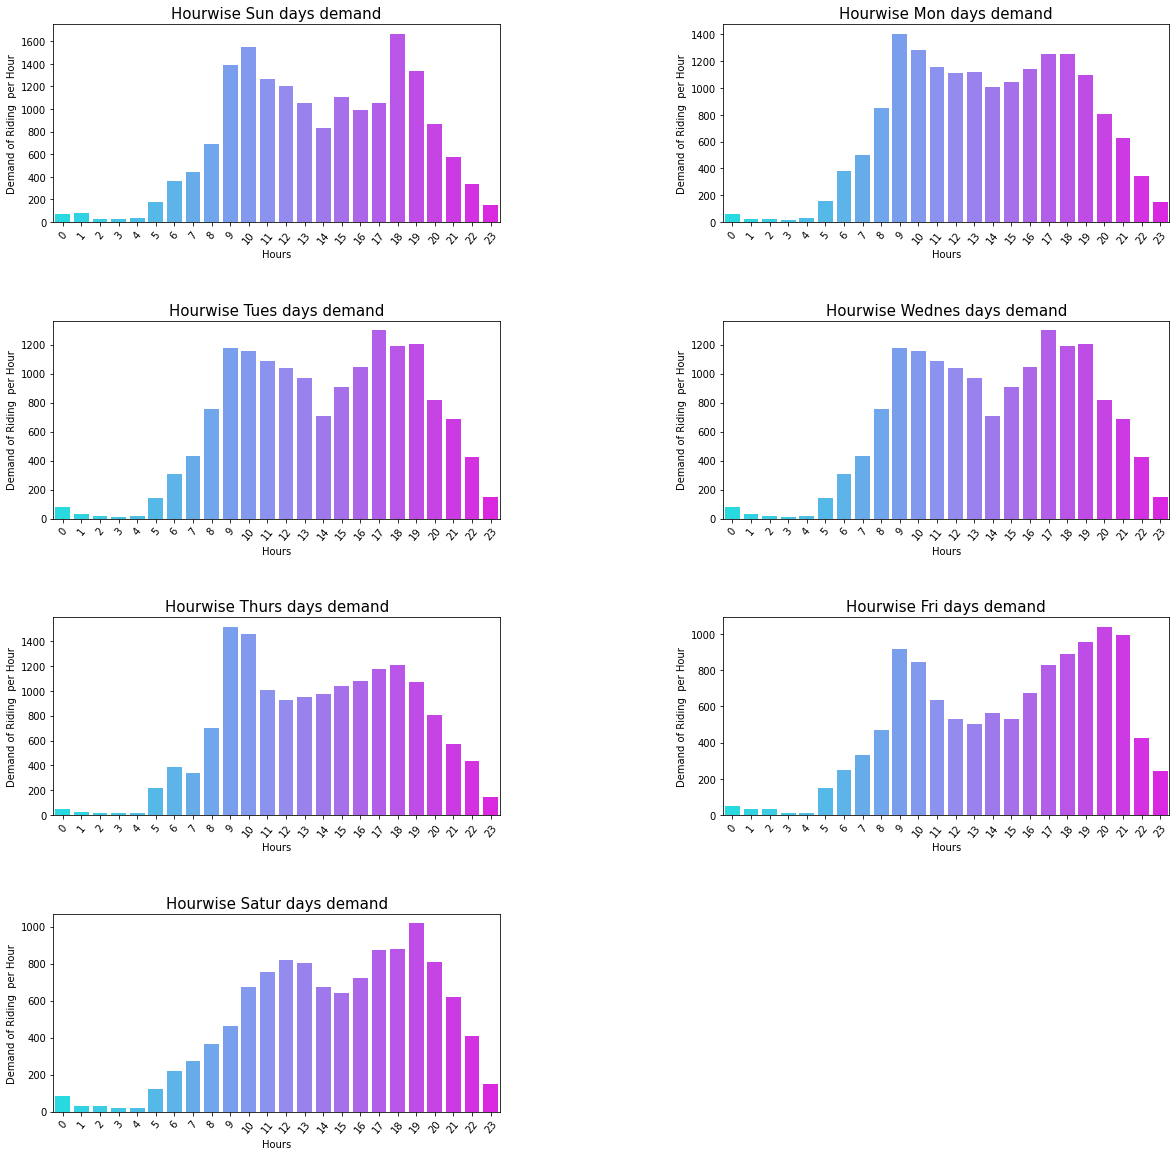

In [ ]:
plt.figure(1,figsize=(20,20))
n=0
for i in ['Sun days demand','Mon days demand','Tues days demand','Wednes days demand','Thurs days demand','Fri days demand','Satur days demand']:
    n+=1
    plt.subplot(4,2,n)
    plt.subplots_adjust(hspace=0.5,wspace=0.5)
    sns.barplot(x='Hour',y=df_day_req[i],data=df_day_req, palette='cool')
    plt.xticks(rotation=50)
    plt.xlabel('Hours',fontsize=10)
    plt.ylabel('Demand of Riding  per Hour',fontsize=10)
    plt.title('Hourwise {}'.format(i),fontsize=15)
plt.show()




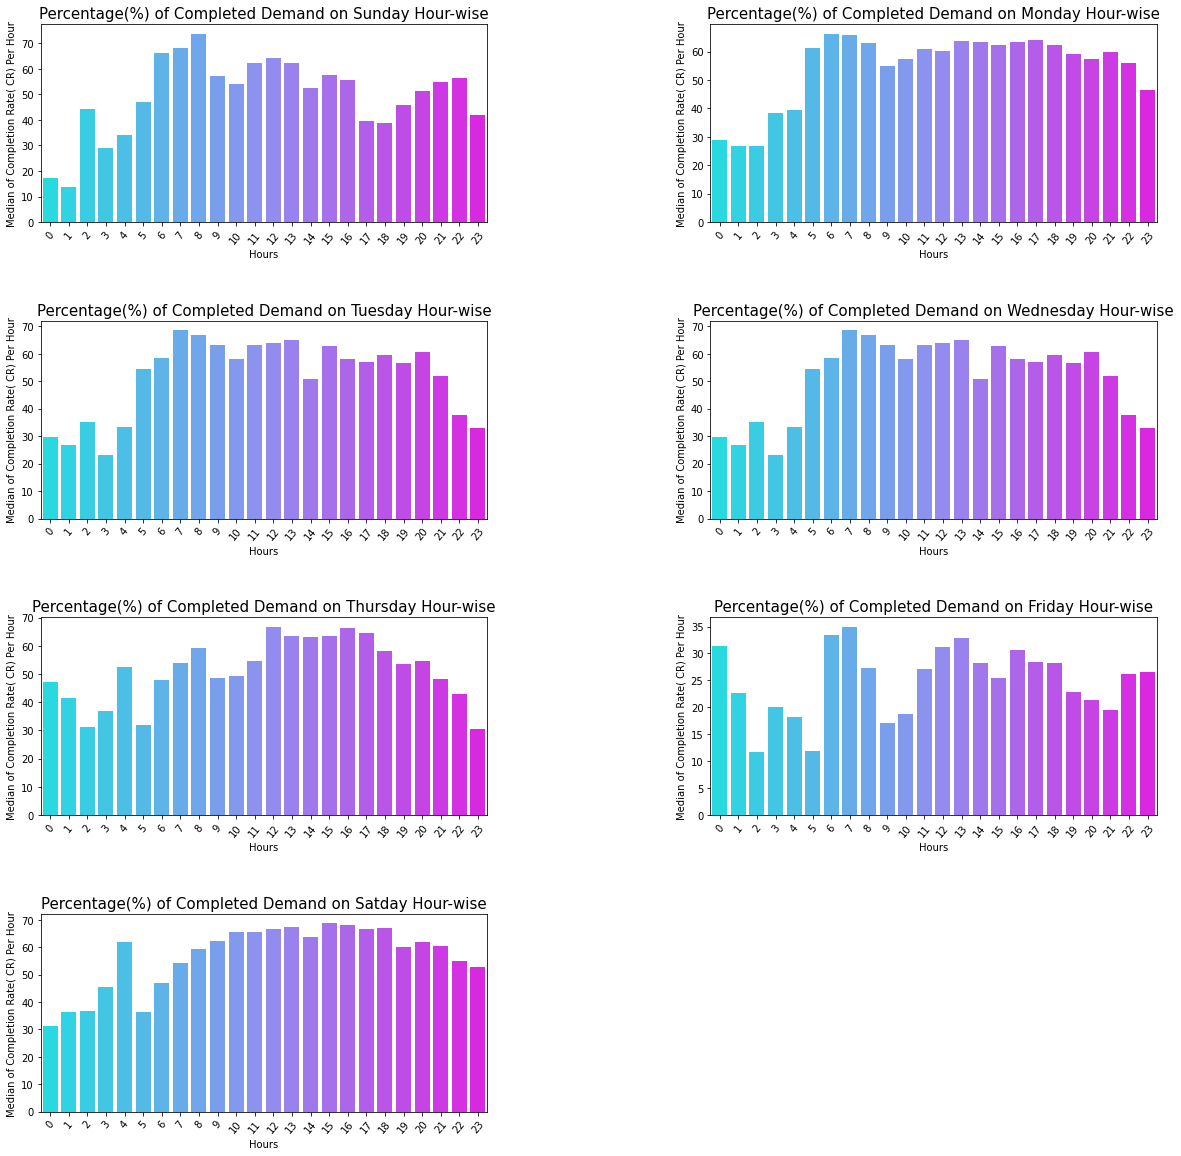

In [ ]:
plt.figure(1,figsize=(20,20))
n=0
for i in ['Percentage(%) of Completed Demand on Sunday','Percentage(%) of Completed Demand on Monday','Percentage(%) of Completed Demand on Tuesday','Percentage(%) of Completed Demand on Wednesday',
                                          'Percentage(%) of Completed Demand on Thursday','Percentage(%) of Completed Demand on Friday','Percentage(%) of Completed Demand on Satday']:
    n+=1
    plt.subplot(4,2,n)
    plt.subplots_adjust(hspace=0.5,wspace=0.5)
    sns.barplot(x='Hour',y=df_day_com[i],data=df_day_com, palette='cool')
    plt.xticks(rotation=50)
    plt.xlabel('Hours',fontsize=10)
    plt.ylabel('Median of Completion Rate( CR) Per Hour',fontsize=10)
    plt.title('{} Hour-wise'.format(i),fontsize=15)
plt.show()




### **Observation**
In case of Demand of riding according to hours per days ; we can say that,\
From the above line-plot and count-plot in case of x='Hour' and y='Day-wise demannd', we can say that,
- In Sundays the demand is high arround 9 AM and 6 PM and Low duing midnight.
- In Mondays the demand is high arround 9 AM and 5 to 6 PM and Low duing midnight.
- In tuesdays the demand is high arround 9 to 10  AM and 5 to 7 PM and Low duing midnight.
- In Wednesdays the demand is high arround 9 to 10  AM and 5 to 7 PM and Low duing midnight.
- In Thursdays the demand is high arround 9 to 10 AM and Low duing midnight.
- In Fridays the demand is high arround 9 to 10 AM and 8 tp 9 PM and Low duing midnight.
- In Saturdays the demand is high arround 7 PM and comparatively Low other time.

From the above line-plot and count-plot in case of x='Hour' and y='Day-wise Completion Rate (%)', we can say that,

- In Sundays the Reliability is high arround 9 AM and comparatively Low other time..
- In Mondays the demand is high arround 6 to 7 AM and 1 to 5 PM and comparatively Low other time..
- In tuesdays the demand is high arround 7 to 8 and Low duing midnight.
- In Wednesdays the demand is high arround 7 to 8  AM and 11AM to 1 PM PM and Low duing midnight.
- In Thursdays the demand is high arround 12 PM and 4 to 5 PM and comparatively Low other time..
- In Fridays the demand is high arround 6 to 7 AM and comparatively Low other time..
- In Saturdays the demand is high arround 3 to 6 PM and comparatively Low other time.

==> Overall Demand and Reliability(% of Completed Demand) both is high During Sunday

## **Based on your analysis do you have any actionable insights for improving reliability?**

### **Insights**

From the above analysis we can say that; 
- As Reliability have a negative correlation with the number of cancelled trip value and the cancellation Rate(%), So if we can decrease the ammount of cancelled trip amount then the Reliability can be increased.
- Again, along with that if we can increase the amount of completed trip or assignment to completion rate of the drivers then the  Reliability can also be increased.
- As the Demands of Ride is high during office days particularly from Sunday and low During off days particularly Friday and Saturdays, that's why if we can increase the Demand Completion rate during Office days then the Reliability can also be increased.
- Again as the demand is high during 9 to 10 and 6 to 7 PM in a day.So, If we can increase the % of completion rate during this hours in a day then the Reliability can be increased.

other-than that I think if we can initially check that the cancelation of riding request is occurring from which side ; driver side or customer side and the reason behind that cancellation, then we could have analize the data more effeciently.

### **Thank You..!**